# E01:

I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

# Analysis

**Setup:** all Linear $W$ and $b$ are zero. BatchNorm $\gamma$ starts at **ones** (last one scaled to $0.1$) and $\beta$ at zero.

## Forward pass: everything is zero
- Linear: $y = xW + b = 0$ (since $W=0,\ b=0$).
- Tanh: $\tanh(0) = 0$.
- BatchNorm: input is constant $0$, so $\mu=0$, $\sigma^2=0$, $\hat{x} = \dfrac{0-0}{\sqrt{\varepsilon}} = 0$, and $\text{out} = \gamma\hat{x} + \beta = 0$.

So all logits are $0$ and the initial loss is $\log(27) = 3.2958$ (uniform).

## Backward pass: the gradient is blocked

For a Linear layer $\text{out} = xW + b$ with $x\in\mathbb{R}^{B\times f_{in}}$, $W\in\mathbb{R}^{f_{in}\times f_{out}}$, the two gradients are

$$
\frac{\partial L}{\partial W} = x^{\top}\,\frac{\partial L}{\partial \text{out}}
\qquad\text{(depends on the input } x\text{)}
$$

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial \text{out}}\,W^{\top}
\qquad\text{(depends on the weights } W\text{)}
$$

The input gradient is **multiplied by $W^{\top}$**, so with $W=0$:

$$
\frac{\partial L}{\partial x} = \frac{\partial L}{\partial \text{out}}\,\cdot 0 = 0 .
$$

Since $\partial L/\partial x$ is exactly the $\partial L/\partial \text{out}$ handed to the layer below, the signal is killed at the *last* Linear and **cannot flow upstream at all**. Every parameter before the last two layers receives exactly zero gradient and stays frozen at init forever. *This* is why only part of the network trains.

Only the last two layers see any gradient, and even there:

| param | grad | trained? | why |
|---|---|---|---|
| last Linear $W$ | $0$ | no | $\partial L/\partial W = x^{\top}\,\partial L/\partial \text{out} = 0$, its input $x$ is $0$ |
| last Linear $b$ | $\approx 0$ (≈2e-7) | effectively no | $\partial L/\partial b = \sum_i \partial L/\partial \text{out}_i$ is nonzero, but it's constant across the batch so the following BatchNorm subtracts it away as the mean |
| last BN $\gamma$ | $0$ | no | $\partial L/\partial \gamma = \sum (\partial L/\partial \text{out}\cdot \hat{x}) = 0$ since $\hat{x}=0$ |
| last BN $\beta$ | nonzero (~3e-2) | **yes** | $\partial L/\partial \beta = 1$; the only parameter that actually learns |

(Confirmed by the grad-distribution cell: the only params with nonzero grad are the three $(27,)$ tensors of the final layers; $\gamma$ is numerical noise.)

## Conclusion: what is trained exactly

**Effectively only $\beta$ of the final BatchNorm learns.** Since it is added to constant (zero) logits, the network can only produce **input-independent constant logits**, i.e. it learns the **unigram marginal distribution** of the next character. That is why loss falls to $\sim 2.5$ (better than random $3.29$) but plateaus at a bad value — it learns letter frequencies and nothing input-dependent.


In [100]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt     # for making figures
%matplotlib inline

In [101]:
# read all the words
words = open('../name.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [102]:
len(words)

32033

In [103]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(set(''.join(words)))
stoi = {s : i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i : s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [104]:
# build the dataset
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]    # crop and append
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1 : n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [105]:
g = torch.Generator().manual_seed(2147483647)   # for reproducibility

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.zeros((fan_in, fan_out))
        self.bias = torch.zeros(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        # parameters (trained with backpro)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        # buffers (trained with a sunning 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)
    
    def __call__(self, x):
        # calculcate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True)   # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)    # normalize to unit variance
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    
    def parameters(self):
        return []

In [106]:
n_emb = 10  # the demensionality of the character embedding vectors
n_hidden = 100  # the number of the neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_emb),             generator=g)
layers = [
    Linear(n_emb * block_size, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, n_hidden), BatchNorm1d(n_hidden), Tanh(),
    Linear(          n_hidden, vocab_size), BatchNorm1d(vocab_size),
]

with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1
    layers[-1].gamma *= 0.1
    # all other layers: appy gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

47551


In [107]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size, ), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]   # batch X, Y

    # forward pass
    emb = C[Xb]     # embed the characters into vectors
    x = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)  # loss functions

    # backward pass
    for layer in layers:
        layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01    # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad
    
    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    # break   # AFTER_DEBUG: take out break to run full optimization

      0/ 200000: 3.2958
  10000/ 200000: 2.7882
  20000/ 200000: 2.7518
  30000/ 200000: 2.8506
  40000/ 200000: 2.8221
  50000/ 200000: 2.8987
  60000/ 200000: 2.6038
  70000/ 200000: 2.6751
  80000/ 200000: 3.0131
  90000/ 200000: 2.7753
 100000/ 200000: 2.6079
 110000/ 200000: 2.5352
 120000/ 200000: 2.6702
 130000/ 200000: 2.6442
 140000/ 200000: 2.8332
 150000/ 200000: 2.5482
 160000/ 200000: 2.9762
 170000/ 200000: 2.9521
 180000/ 200000: 2.8626
 190000/ 200000: 2.8505


layer 0 (    Linear): mean +0.00, std 0.00 saturated: 0.00%
layer 1 (BatchNorm1d): mean +0.00, std 0.00 saturated: 0.00%
layer 2 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%
layer 3 (    Linear): mean +0.00, std 0.00 saturated: 0.00%
layer 4 (BatchNorm1d): mean +0.00, std 0.00 saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%
layer 6 (    Linear): mean +0.00, std 0.00 saturated: 0.00%
layer 7 (BatchNorm1d): mean +0.00, std 0.00 saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%
layer 9 (    Linear): mean +0.00, std 0.00 saturated: 0.00%
layer 10 (BatchNorm1d): mean +0.00, std 0.00 saturated: 0.00%
layer 11 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%
layer 12 (    Linear): mean +0.00, std 0.00 saturated: 0.00%
layer 13 (BatchNorm1d): mean +0.00, std 0.00 saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%
layer 15 (    Linear): mean -0.00, std 0.00 saturated: 0.00%
layer 16 (BatchNorm1d): mean 

Text(0.5, 1.0, 'activation distribution')

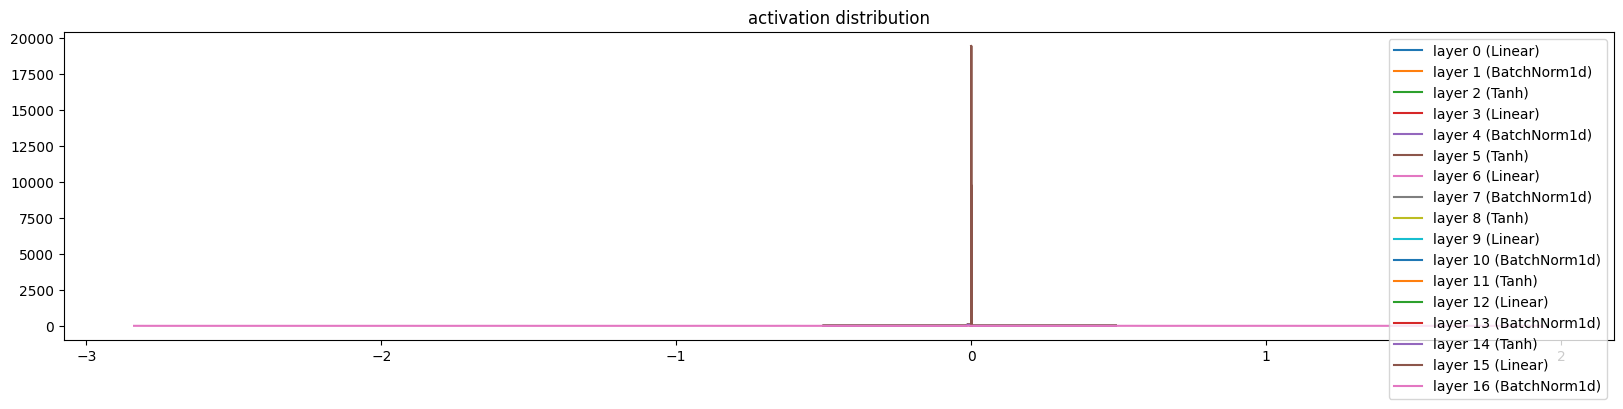

In [142]:
# visualize the activation
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers):
    if True:
        t = layer.out.detach()
        print('layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 16 (BatchNorm1d): mean -0.00, std 1.22 saturated: 44.44%


Text(0.5, 1.0, 'activation distribution')

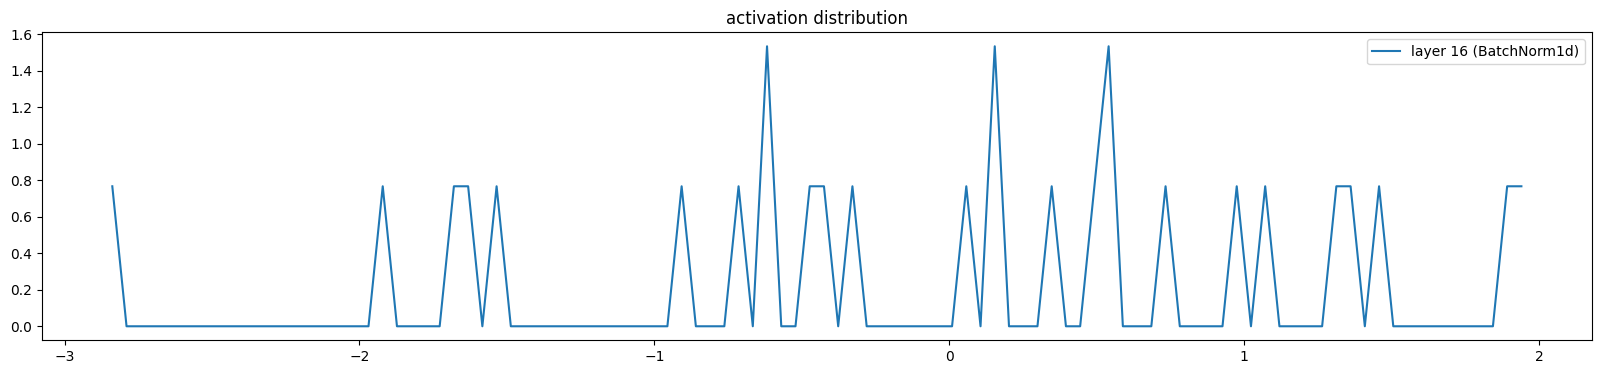

In [ ]:
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers):
    if i == 16:
        t = layer.beta.detach()
        print('layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean() * 100))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('activation distribution')

layer 15 (    Linear): mean -0.00, std 0.00 saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

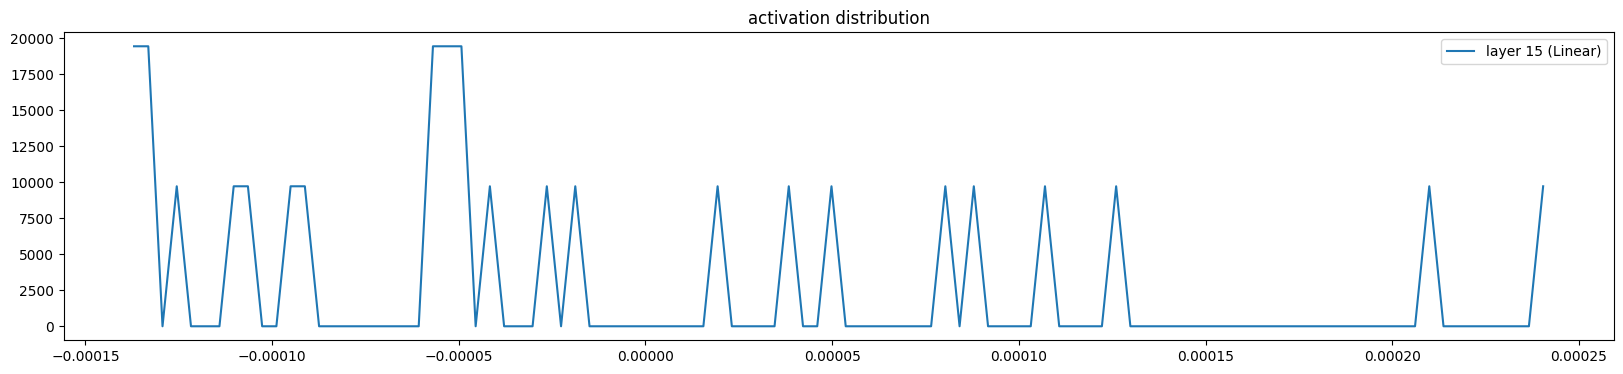

In [129]:
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers):
    if i == 15:
        t = layer.bias.detach()
        print(
            "layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%"
            % (
                i,
                layer.__class__.__name__,
                t.mean(),
                t.std(),
                (t.abs() > 0.97).float().mean() * 100,
            )
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends)
plt.title("activation distribution")

layer 14 (      Tanh): mean +0.00, std 0.00 saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

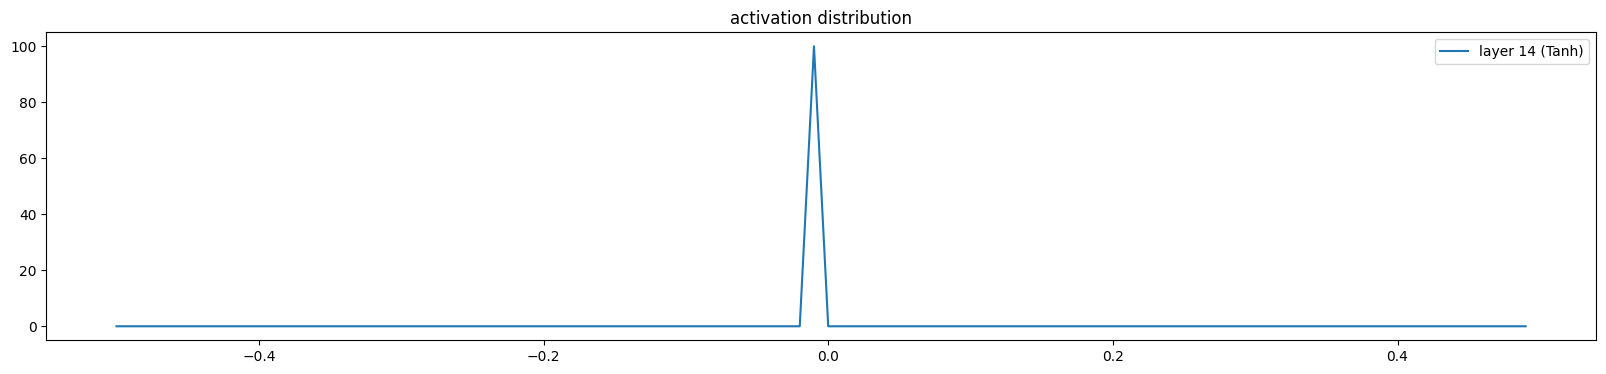

In [130]:
plt.figure(figsize=(20, 4))  # width and height of the plot
legends = []
for i, layer in enumerate(layers):
    if i == 14:
        t = layer.out.detach()
        print(
            "layer %d (%10s): mean %+.2f, std %.2f saturated: %.2f%%"
            % (
                i,
                layer.__class__.__name__,
                t.mean(),
                t.std(),
                (t.abs() > 0.97).float().mean() * 100,
            )
        )
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends)
plt.title("activation distribution")

layer 15 (    Linear): mean -0.000000, std 1.776037e-01
layer 16 (BatchNorm1d): mean -0.000000, std 5.689012e-03


Text(0.5, 1.0, 'gradient distribution')

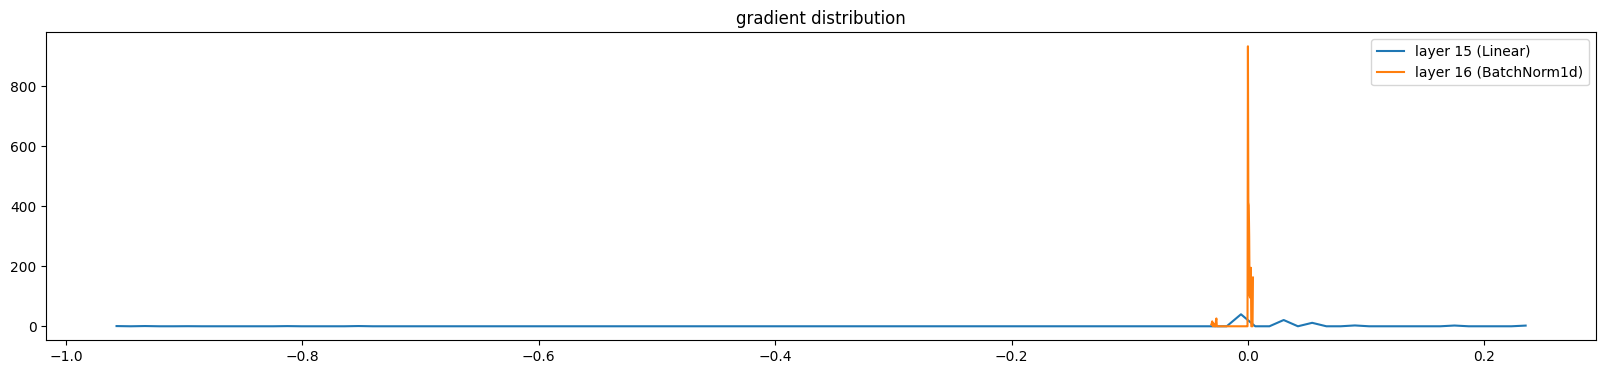

In [123]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers):
    # if isinstance(layer, Linear):
    if i == 15 or i == 16:
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__})')
plt.legend(legends)
plt.title('gradient distribution')

weight      (27,) | mean -0.000000 | std 2.092218e-07 | grad:data ratio 1.991119e-03
weight      (27,) | mean +0.000000 | std 1.472865e-10 | grad:data ratio 1.939892e-02
weight      (27,) | mean -0.000000 | std 2.954402e-02 | grad:data ratio 2.411847e-02


Text(0.5, 1.0, 'weights gradient distribution')

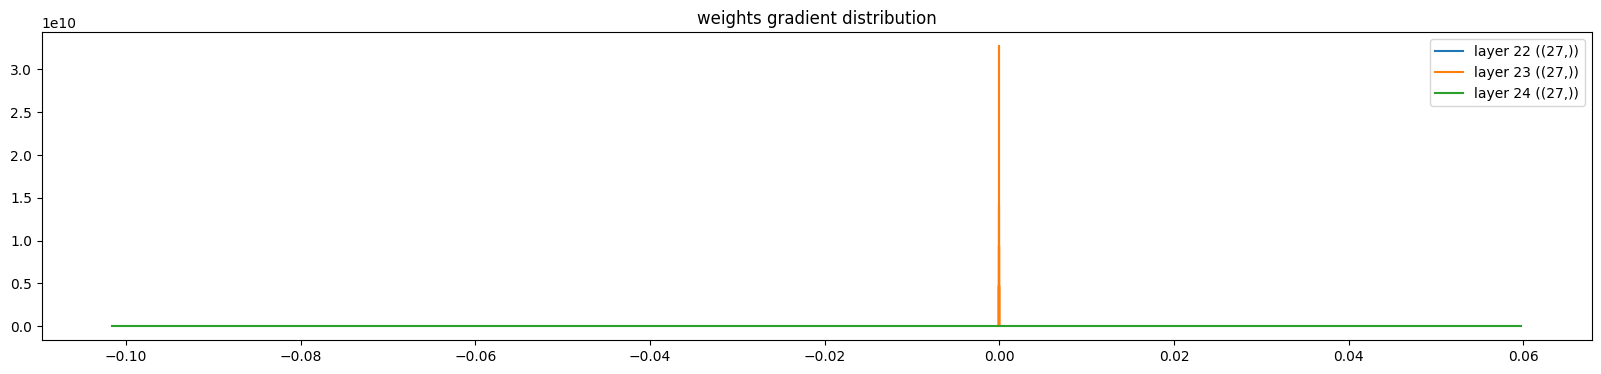

In [141]:
# visualize the gradient
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if not (t == 0).all().item():
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std())) 
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({tuple(p.shape)})')
plt.legend(legends)
plt.title('weights gradient distribution')